In [53]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('../tracking')

from loader import create_trk_dataloaders
from visualization import PositionAnimationBuilder, CellAnimationBuilder
import matplotlib.pyplot as plt

config = {
    "optimizer": "radam",
    "learning_rate": 1e-3,
    "weight_decay": 0,
    "decay": 0.99,
    "scheduler": "reduce_on_plateau",
    "max_epochs": 30,
    "batch_size": 4,
    "n_layers": 1,
    "num_workers": 0,
    "clipnorm": 0.001,
    "step_size": 5,
    "crop_mode": "resize",
    "patience": 3,
    "log_and_save": True,
    "enable_early_stopping": False,
    "crop_size": 32,
    "attention": False,
    "truncate_dataset": None,
    "loss": "cce",
    "t_direction": "forward",
    "processed": True,
    "dropout": 0,
    "device": "cuda:0",
    "label_smoothing": False,
    "stopping_metric": 'loss'
}

train_loader, val_loader, _ = create_trk_dataloaders(
    train_path='/data/shared/caliban/DynamicNuclearNet-tracking-v1_0/test_proc.zarr',
    val_path='/data/shared/caliban/DynamicNuclearNet-tracking-v1_0/val_proc.zarr',
    batch_size=config['batch_size'],
    distance_threshold=64,
    num_workers=0,
    truncate_dataset = config['truncate_dataset'],
    t_direction=config['t_direction'],
    translation_range=10
    )

data_iterator = iter(val_loader)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0it [00:00, ?it/s]

5it [00:00,  9.26it/s]


  Created 497 samples


5it [00:01,  3.27it/s]

  Created 1045 samples


In [54]:
data = next(data_iterator)

In [30]:
centroids = data['centroids'][0]
appearances = data['appearances'][0]

plotter = PositionAnimationBuilder(figsize=(10,10))
for i in range(centroids.shape[0]):
    plotter.add_frame(
        x_positions=centroids[i,:,1],
        y_positions=centroids[i,:,0],
        image = appearances[i]
    )
plotter.show(interval=200)

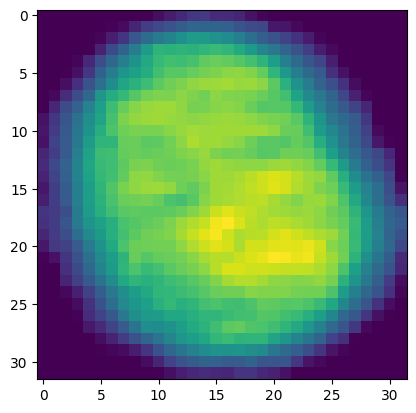

In [55]:
plt.imshow(appearances[1,10].squeeze())

In [105]:
import zarr

z = zarr.open('/data/shared/caliban/DynamicNuclearNet-tracking-v1_0/train_proc.zarr')

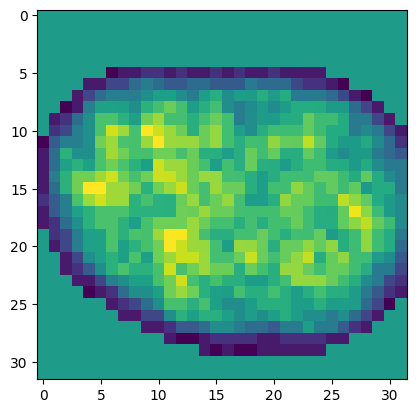

In [106]:
plt.imshow(z['appearances'][0,5,14].squeeze())